In [1]:
import jax.numpy as np
import jax.random as random
import optimize
import projections
rand_key = random.key(123)

In [ ]:
## setup problem
xor_X = np.array([[0, 1, 0, 1],
                  [0, 0, 1, 1]])
xor_y = np.array([0, 1, 1, 1])

### define weight matrices
W0 = random.uniform(rand_key,(2,3))
W1 = random.uniform(rand_key,3)
b0 = 1
b1 = 1

## set the value for positive class
delta = 1

In [20]:
optimizer = optimize.AlternatingProjection

final error 0.4793595


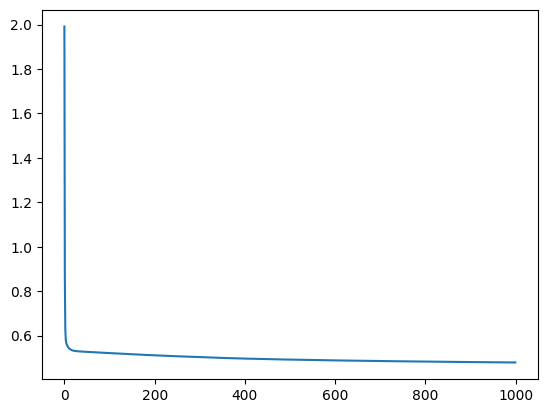

In [21]:
## implementation using alternating Projections
error = []
optInput = optimizer([projections.pos],[projections.bilinearMatrix])
optHidden = optimizer([], [projections.bilinearProj])
optOutput= optimizer([lambda x,w,y :projections.classifierOutput(x,w,y,delta=delta)], [])
error = []
for iter in range(1000):
    batchError = np.zeros(len(xor_y))
    for k, classSample in enumerate(xor_y):
        ## do a forward pass
        x_in = xor_X[:,k]
        x_in_aug = np.append(x_in, b0)
        x_hidden = np.maximum(W0 @ x_in_aug, 0) # perform relu
        x_hidden_aug = np.append(x_hidden, b1)
        x_out = W1 @ x_hidden_aug
        
        ## calculate error
        if classSample==1:
            batchError = batchError.at[k].set((x_out - delta)**2 if x_out < delta else 0)
        else:
            batchError = batchError.at[k].set((x_out)**2 if x_out > 0 else 0)

        ## optimize output layer
        x_out, _, _ = optOutput.step_layer(x_out, np.eye(1), classSample)
        ## optimize hidden layer
        x_hidden_aug, w1_proj, x_out = optHidden.step_layer(x_hidden_aug, W1, x_out)
        x_hidden= x_hidden_aug[:][:-1]
        ## optimize input layer
        x_in_aug, w0_proj, x_hidden = optInput.step_layer(x_in_aug, W0, x_hidden)
        
        b1 = b1 + (1/(k+1))*(x_hidden_aug[:][-1] - b1) # do consenus update on b1
        b0 = b0 + (1/(k+1))*(x_in_aug[:][-1] - b0) # do consenus update on b0
        W0 = W0 + (1/(k+1))*(w0_proj - W0)
        W1 = W1 + (1/(k+1))*(w1_proj - W1)
    error.append(np.mean(batchError))

import matplotlib.pyplot as plt
plt.plot(error)
print("final error", error[-1])